# 01 — Environment Check & Data Loading
**Project:** A Data-Driven Predictive Control Framework for HVAC Cooling Optimisation  
**Author:** Cheuk Fung Donald Man  
**Institution:** Imperial College London, MEng Civil Engineering  

---
This notebook:
1. Verifies all required packages are installed
2. Connects to the AlphaBuilding dataset on AWS S3
3. Explores the HDF5 file structure
4. Loads a representative set of simulations into a clean DataFrame
5. Saves the extracted data locally for use in subsequent notebooks

## 1. Package Check

In [1]:
# Run this cell first — it will tell you if anything is missing
import importlib, sys

REQUIRED = [
    'h5py', 's3fs', 'pandas', 'numpy',
    'matplotlib', 'seaborn', 'sklearn', 'tqdm'
]

missing = []
for pkg in REQUIRED:
    if importlib.util.find_spec(pkg) is None:
        missing.append(pkg)

if missing:
    print(f'Missing packages: {missing}')
    print('Run:  pip install -r requirements.txt')
else:
    print('All packages installed.')
    print(f'Python {sys.version}')

All packages installed.
Python 3.9.6 (default, Jan  9 2026, 11:03:41) 
[Clang 17.0.0 (clang-1700.6.4.2)]


## 2. Imports

In [2]:
import h5py
import s3fs
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot defaults
plt.rcParams.update({
    'figure.dpi'        : 120,
    'font.family'       : 'sans-serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

# Output folders
DATA_OUT    = Path('../data/processed')
FIGURES_OUT = Path('../figures')
DATA_OUT.mkdir(parents=True, exist_ok=True)
FIGURES_OUT.mkdir(parents=True, exist_ok=True)

# Constants
J_TO_KWH = 1 / 3_600_000

CLIMATE_ZONES = {
    '1A': 'Miami, FL (Hot/Humid)',
    '3C': 'San Francisco, CA (Marine)',
    '5A': 'Chicago, IL (Cold)',
}

CLIMATE_COLOURS = {
    '1A': '#E24B4A',
    '3C': '#2E75B6',
    '5A': '#639922',
}

print('Imports OK.')

Imports OK.


## 3. Connect to S3

> The OEDI S3 bucket is **public** — no AWS account or credentials needed.  
> `anon=True` handles this automatically.

In [3]:
S3_PATH = 's3://oedi-data-lake/building_synthetic_dataset/A_Synthetic_Building_Operation_Dataset.h5'

print('Connecting to S3...')
s3  = s3fs.S3FileSystem(anon=True)   # anon=True — public bucket, no credentials needed
hdf = h5py.File(s3.open(S3_PATH, 'rb'), 'r')
print('Connected successfully!')

# Top-level structure
print('\nTop-level keys:')
for key in hdf.keys():
    print(f'  {key}')

Connecting to S3...
Connected successfully!

Top-level keys:
  1. README
  2. Resources
  3. Data


## 4. Explore the HDF5 Structure

In [4]:
# Print full inventory of what's available
ts_root = hdf['3. Data']['3.2. Timeseries']

print('=' * 60)
print('Available simulations in the dataset')
print('=' * 60)
for climate in ts_root.keys():
    label = CLIMATE_ZONES.get(climate, climate)
    print(f'\nClimate zone {climate}  ({label})')
    for eff in ts_root[climate].keys():
        years = list(ts_root[climate][eff].keys())
        runs  = list(ts_root[climate][eff][years[0]].keys())
        print(f'  Efficiency: {eff}')
        print(f'    Years : {years[:3]} ... {years[-1]}  ({len(years)} total)')
        print(f'    Runs  : {runs}')
print('=' * 60)

Available simulations in the dataset


KeyboardInterrupt: 

In [ ]:
# All variable names available in one simulation
sample = ts_root['1A']['Standard']['TMY3']['run_1']
variables = list(sample.keys())
print(f'{len(variables)} variables available:')
for v in variables:
    print(f'  {v}')

## 5. Data Extraction Functions

In [4]:
def extract_variable(hdf, climate, efficiency, year, run, variable):
    """Extract one variable from one simulation as a DataFrame."""
    node  = hdf['3. Data']['3.2. Timeseries'][climate][efficiency][year][run][variable]
    cols  = np.array(node['axis0'])[1:].astype(str)
    data  = np.array(node['block1_values'])
    index = pd.date_range('2006-01-01', '2007-01-01', freq='10min')[:-1]
    return pd.DataFrame(data, index=index, columns=cols)


def load_simulation(hdf, climate='1A', efficiency='Standard',
                    year='TMY3', run='run_1'):
    """
    Load one full simulation into a clean, feature-rich DataFrame.
    All energy columns are converted from J to kWh.
    Temporal and rolling features are added automatically.
    """
    def get(var):
        return extract_variable(hdf, climate, efficiency, year, run, var)

    df = pd.DataFrame(index=pd.date_range('2006-01-01', '2007-01-01', freq='10min')[:-1])

    # Energy → kWh
    df['hvac_kwh']      = get('ElectricityHVAC').iloc[:, 0]              * J_TO_KWH
    df['total_kwh']     = get('ElectricityFacility').iloc[:, 0]          * J_TO_KWH
    df['gas_kwh']       = get('GasFacility').iloc[:, 0]                  * J_TO_KWH
    df['lighting_kwh']  = get('InteriorLightsElectricity').iloc[:, 0]    * J_TO_KWH
    df['plugloads_kwh'] = get('InteriorEquipmentElectricity').iloc[:, 0] * J_TO_KWH

    # Outdoor air temperatures
    df['oat_c']      = get('SiteOutdoorAirDrybulbTemperature').iloc[:, 0]
    df['wetbulb_c']  = get('SiteOutdoorAirWetbulbTemperature').iloc[:, 0]

    # Occupancy — sum across all zones
    df['occupancy'] = get('ZonePeopleOccupantCount').sum(axis=1)

    # Indoor zone temperature — mean across all zones
    df['indoor_temp_c'] = get('ZoneMeanAirTemperature').mean(axis=1)

    # Cooling and heating electricity breakdown — kWh
    df['cooling_kwh'] = get('CoolingElectricity').iloc[:, 0] * J_TO_KWH
    df['heating_kwh'] = get('HeatingElectricity').iloc[:, 0] * J_TO_KWH

    # Temporal features
    df['hour']       = df.index.hour
    df['minute']     = df.index.minute
    df['dayofweek']  = df.index.dayofweek
    df['month']      = df.index.month
    df['is_weekday'] = (df.index.dayofweek < 5).astype(int)
    df['is_occupied'] = (
        (df.index.dayofweek < 5) &
        (df.index.hour >= 7)     &
        (df.index.hour < 20)
    ).astype(int)

    # Rolling weather features
    df['oat_roll1h'] = df['oat_c'].rolling(6,  min_periods=1).mean()
    df['oat_roll3h'] = df['oat_c'].rolling(18, min_periods=1).mean()

    # Metadata
    df['climate']    = climate
    df['efficiency'] = efficiency
    df['year']       = year
    df['run']        = run

    return df


print('Functions defined.')

Functions defined.


## 6. Load Data

Loading the **TMY3 reference year** across all **3 climate zones** and **3 efficiency levels** with **run_1**.  
This gives 9 simulations × 52,560 rows = **473,040 rows** — a solid starting set for EDA.

In [18]:
CLIMATES   = ['1A', '3C', '5A']   # Miami | San Francisco | Chicago
EFFICIENCY = 'Standard'
YEAR       = 'TMY3'
RUN        = 'run_1'

frames = []
for climate in CLIMATES:
    print(f'Loading: climate={climate}, efficiency={EFFICIENCY}, year={YEAR}, run={RUN}')
    frames.append(load_simulation(hdf, climate=climate, efficiency=EFFICIENCY, year=YEAR, run=RUN))

df = pd.concat(frames)
print(f'\nDone — {len(df):,} rows loaded across {len(CLIMATES)} climate zones.')

Loading: climate=1A, efficiency=Standard, year=TMY3, run=run_1
Loading: climate=3C, efficiency=Standard, year=TMY3, run=run_1
Loading: climate=5A, efficiency=Standard, year=TMY3, run=run_1

Done — 157,680 rows loaded across 3 climate zones.


## 7. First Look

In [19]:
print(f'Shape : {df.shape}')
print(f'Dates : {df.index.min()}  →  {df.index.max()}')
df.head()

Shape : (157680, 23)
Dates : 2006-01-01 00:00:00  →  2006-12-31 23:50:00


,hvac_kwh,total_kwh,gas_kwh,lighting_kwh,plugloads_kwh,oat_c,wetbulb_c,occupancy,indoor_temp_c,cooling_kwh,...,dayofweek,month,is_weekday,is_occupied,oat_roll1h,oat_roll3h,climate,efficiency,year,run
2006-01-01 00:00:00,1.120481,5.586690,0.212824,0.821181,2.772776,20.4,19.253145,0.0,23.298959,0.985418,...,6,1,0,0,20.4,20.4,1A,Standard,TMY3,run_1
2006-01-01 00:10:00,2.966786,7.432995,0.212824,0.821181,2.772776,20.2,19.058898,0.0,23.058716,2.692995,...,6,1,0,0,20.3,20.3,1A,Standard,TMY3,run_1
2006-01-01 00:20:00,2.868515,7.334724,0.212824,0.821181,2.772776,20.0,18.864666,0.0,22.912473,2.602989,...,6,1,0,0,20.2,20.2,1A,Standard,TMY3,run_1
2006-01-01 00:30:00,0.000000,4.466209,0.212824,0.821181,2.772776,19.8,18.670431,0.0,23.331472,0.000000,...,6,1,0,0,20.1,20.1,1A,Standard,TMY3,run_1
2006-01-01 00:40:00,2.985302,7.451511,0.212824,0.821181,2.772776,19.6,18.476204,0.0,22.987425,2.705319,...,6,1,0,0,20.0,20.0,1A,Standard,TMY3,run_1


In [20]:
# Missing value check — should be zero for simulation data
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0] if missing.any() else '  None — dataset is complete.')

Missing values:
  None — dataset is complete.


In [21]:
# Summary statistics — Standard efficiency only
cols = ['hvac_kwh', 'total_kwh', 'oat_c', 'occupancy', 'lighting_kwh', 'plugloads_kwh']
df[df['efficiency'] == 'Standard'][cols].describe().round(4)

,hvac_kwh,total_kwh,oat_c,occupancy,lighting_kwh,plugloads_kwh
count,157680.0000,157680.0000,157680.0000,157680.0000,157680.0000,157680.0000
mean,3.5952,11.1966,16.0962,33.1668,2.4327,4.6132
std,3.8205,7.3775,9.7333,56.1653,2.3406,2.5190
min,0.0000,1.6111,-22.8000,0.0000,0.1117,0.1494
25%,0.0000,5.0271,11.1000,0.0000,0.8212,2.8226
50%,2.9564,7.9848,16.3000,0.0000,0.9329,2.8702
75%,5.0968,17.8691,23.9000,70.8791,5.9045,7.7928
max,35.7195,48.6927,35.6000,156.0328,6.4641,10.7252


## 8. Sanity Check Plot
Miami (1A) should have the highest cooling demand year-round.  
Chicago (5A) should peak in summer only. San Francisco (3C) should be the lowest overall.

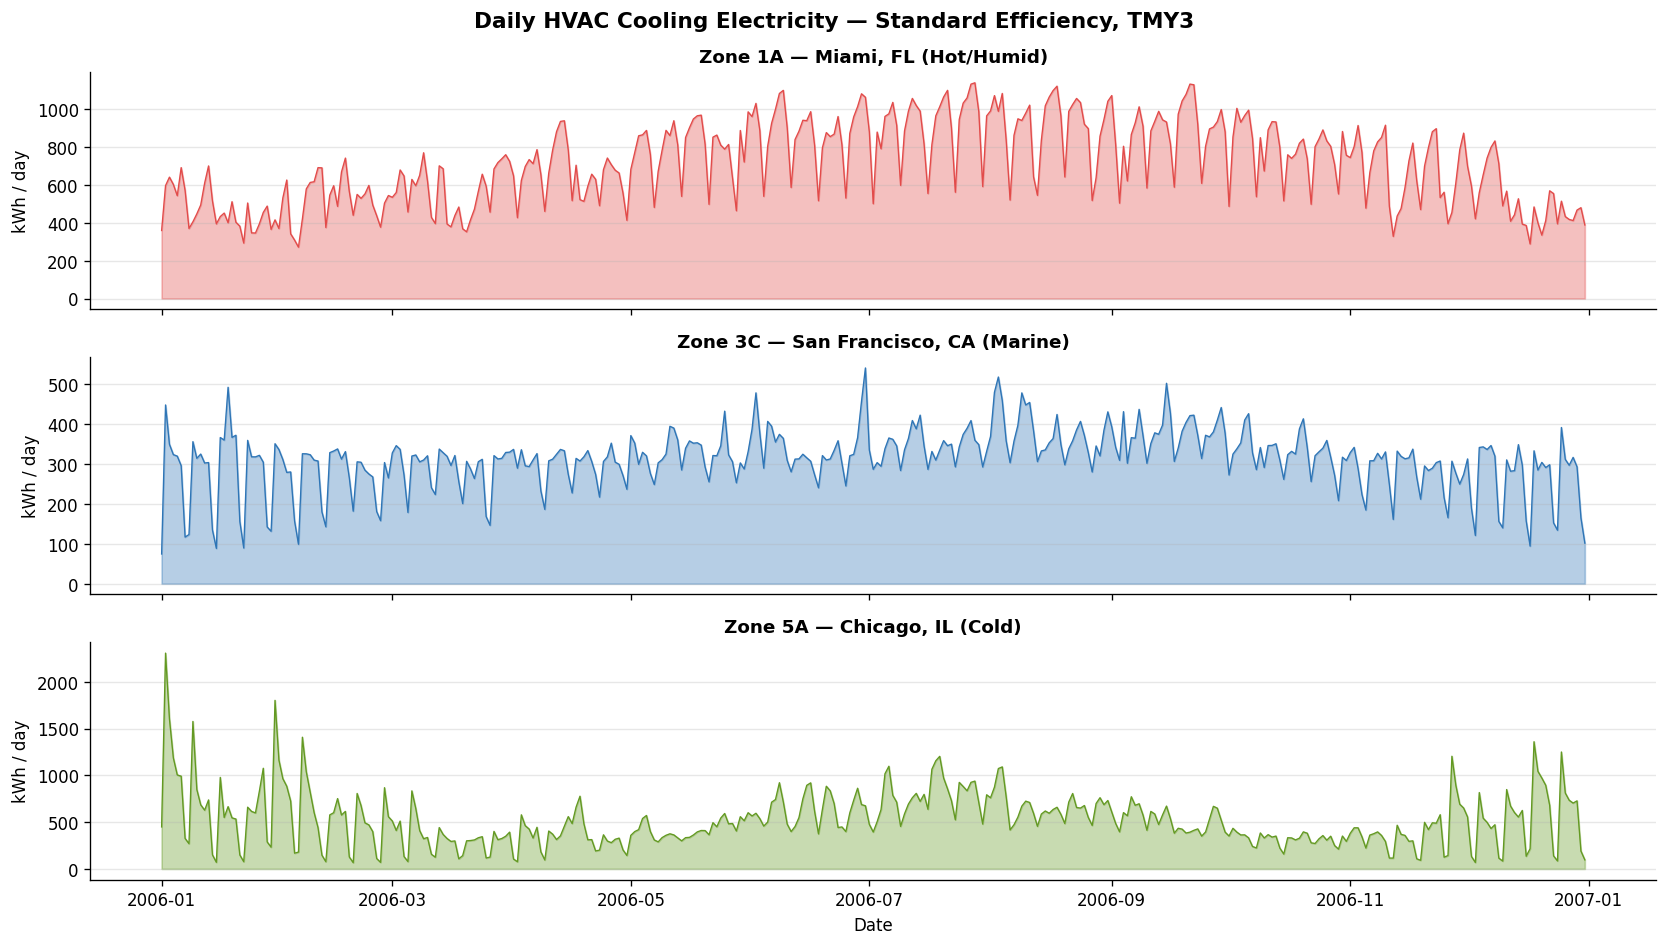

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, (climate, label) in zip(axes, CLIMATE_ZONES.items()):
    subset = df[(df['climate'] == climate) & (df['efficiency'] == 'Standard')]
    daily  = subset['hvac_kwh'].resample('D').sum()

    ax.fill_between(daily.index, daily.values, alpha=0.35, color=CLIMATE_COLOURS[climate])
    ax.plot(daily.index, daily.values, color=CLIMATE_COLOURS[climate], linewidth=0.8)
    ax.set_ylabel('kWh / day', fontsize=10)
    ax.set_title(f'Zone {climate} — {label}', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=10)
fig.suptitle('Daily HVAC Cooling Electricity — Standard Efficiency, TMY3',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_OUT / '01_hvac_daily_by_climate.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Save Locally as Parquet
Saves to `data/processed/` so future notebooks load instantly without re-connecting to S3.

In [23]:
for climate, frame in zip(CLIMATES, frames):
    out = DATA_OUT / f'{YEAR}_{climate}_{EFFICIENCY}_{RUN}.parquet'
    frame.to_parquet(out)
    print(f'Saved → {out}  ({out.stat().st_size / 1e6:.1f} MB)')

    # Verify round-trip
    check = pd.read_parquet(out)
    assert check.shape == frame.shape, f'Shape mismatch for {climate}!'

print('\nAll 3 files verified ✓')

Saved → ../data/processed/TMY3_1A_Standard_run_1.parquet  (3.4 MB)
Saved → ../data/processed/TMY3_3C_Standard_run_1.parquet  (3.6 MB)
Saved → ../data/processed/TMY3_5A_Standard_run_1.parquet  (3.7 MB)

All 3 files verified ✓


---
## Summary

| Item | Value |
|------|-------|
| Simulations loaded (TMY3) | 3 (climates 1A, 3C, 5A — Standard efficiency, TMY3, run_1) |
| Total rows (TMY3) | 157,680 (52,560 × 3 climate zones) |
| Time resolution | 10 minutes |
| Target variable | `hvac_kwh` — total HVAC electricity |
| Saved to | `data/processed/TMY3_1A_Standard_run_1.parquet` |
|  | `data/processed/TMY3_3C_Standard_run_1.parquet` |
|  | `data/processed/TMY3_5A_Standard_run_1.parquet` |

**Section 10 below** loads the expanded multi-year dataset (81 simulations) for robust ML training.

**Next → `02_eda.ipynb`** (uses TMY3 Standard data above)

## 10. Multi-Year Expanded Data Loading

Loads **81 simulations** split into **9 independent cells** (~9 simulations each, ~45 min per cell):

| Cell | Year | Climate | Sims | Output file |
|------|------|---------|------|-------------|
| 10a | 1990 | 1A (Miami) | 9 | `multi_year_1990_1A.parquet` |
| 10b | 1990 | 3C (San Francisco) | 9 | `multi_year_1990_3C.parquet` |
| 10c | 1990 | 5A (Chicago) | 9 | `multi_year_1990_5A.parquet` |
| 10d | 1997 | 1A (Miami) | 9 | `multi_year_1997_1A.parquet` |
| 10e | 1997 | 3C (San Francisco) | 9 | `multi_year_1997_3C.parquet` |
| 10f | 1997 | 5A (Chicago) | 9 | `multi_year_1997_5A.parquet` |
| 10g | 2004 | 1A (Miami) | 9 | `multi_year_2004_1A.parquet` |
| 10h | 2004 | 3C (San Francisco) | 9 | `multi_year_2004_3C.parquet` |
| 10i | 2004 | 5A (Chicago) | 9 | `multi_year_2004_5A.parquet` |

Run **10j** last to combine all 9 parquets into `multi_year_raw.parquet`.

> Each cell saves its own parquet immediately — you can resume across sessions without re-downloading completed cells.

### 10a. Load 1990 / 1A — Miami (9 simulations)

In [5]:
from tqdm import tqdm
import itertools
import time

RUNS_MULTI  = ['run_1', 'run_2', 'run_3']
EFFS_MULTI  = ['Low', 'Standard', 'High']
CLIMS_MULTI = ['1A', '3C', '5A']

MAX_RETRIES = 3
RETRY_DELAY = 10  # seconds between retries

def load_with_retry(hdf, climate, efficiency, year, run, max_retries=MAX_RETRIES):
    """Load one simulation with retry on transient S3 errors."""
    for attempt in range(1, max_retries + 1):
        try:
            return load_simulation(hdf, climate=climate, efficiency=efficiency, year=year, run=run)
        except Exception as e:
            if attempt < max_retries:
                print(f'  Retry {attempt}/{max_retries-1}: {climate}/{efficiency}/{year}/{run} — {e}')
                time.sleep(RETRY_DELAY)
            else:
                raise

combos = list(itertools.product(['1A'], EFFS_MULTI, ['1990'], RUNS_MULTI))
print(f'Simulations to load: {len(combos)}  ({len(combos) * 52_560:,} rows)')

frames, errors = [], []

for climate, eff, year_, run in tqdm(combos, desc='Loading 1990/1A'):
    try:
        frames.append(load_with_retry(hdf, climate, eff, year_, run))
    except Exception as e:
        errors.append((climate, eff, year_, run, str(e)))
        print(f'  FAILED: {climate}/{eff}/{year_}/{run} — {e}')

df = pd.concat(frames)
print(f'\nLoaded: {len(frames)} sims  |  Errors: {len(errors)}  |  Shape: {df.shape}')

out = DATA_OUT / 'multi_year_1990_1A.parquet'
df.to_parquet(out)
print(f'Saved → {out}  ({out.stat().st_size / 1e6:.1f} MB)')


Simulations to load: 9  (473,040 rows)


Loading 1990/1A: 100%|██████████| 9/9 [1:52:55<00:00, 752.85s/it]



Loaded: 9 sims  |  Errors: 0  |  Shape: (473040, 23)
Saved → ../data/processed/multi_year_1990_1A.parquet  (22.2 MB)


### 10b. Load 1990 / 3C — San Francisco (9 simulations)

In [7]:
combos = list(itertools.product(['3C'], EFFS_MULTI, ['1990'], RUNS_MULTI))
print(f'Simulations to load: {len(combos)}  ({len(combos) * 52_560:,} rows)')

frames, errors = [], []

for climate, eff, year_, run in tqdm(combos, desc='Loading 1990/3C'):
    try:
        frames.append(load_with_retry(hdf, climate, eff, year_, run))
    except Exception as e:
        errors.append((climate, eff, year_, run, str(e)))
        print(f'  FAILED: {climate}/{eff}/{year_}/{run} — {e}')

df = pd.concat(frames)
print(f'\nLoaded: {len(frames)} sims  |  Errors: {len(errors)}  |  Shape: {df.shape}')

out = DATA_OUT / 'multi_year_1990_3C.parquet'
df.to_parquet(out)
print(f'Saved → {out}  ({out.stat().st_size / 1e6:.1f} MB)')


Simulations to load: 9  (473,040 rows)


Loading 1990/3C: 100%|██████████| 9/9 [49:27<00:00, 329.69s/it]


Loaded: 9 sims  |  Errors: 0  |  Shape: (473040, 23)
Saved → ../data/processed/multi_year_1990_3C.parquet  (24.1 MB)


### 10c. Load 1990 / 5A — Chicago (9 simulations)

In [8]:
combos = list(itertools.product(['5A'], EFFS_MULTI, ['1990'], RUNS_MULTI))
print(f'Simulations to load: {len(combos)}  ({len(combos) * 52_560:,} rows)')

frames, errors = [], []

for climate, eff, year_, run in tqdm(combos, desc='Loading 1990/5A'):
    try:
        frames.append(load_with_retry(hdf, climate, eff, year_, run))
    except Exception as e:
        errors.append((climate, eff, year_, run, str(e)))
        print(f'  FAILED: {climate}/{eff}/{year_}/{run} — {e}')

df = pd.concat(frames)
print(f'\nLoaded: {len(frames)} sims  |  Errors: {len(errors)}  |  Shape: {df.shape}')

out = DATA_OUT / 'multi_year_1990_5A.parquet'
df.to_parquet(out)
print(f'Saved → {out}  ({out.stat().st_size / 1e6:.1f} MB)')


Simulations to load: 9  (473,040 rows)


Loading 1990/5A: 100%|██████████| 9/9 [1:00:25<00:00, 402.88s/it]


Loaded: 9 sims  |  Errors: 0  |  Shape: (473040, 23)
Saved → ../data/processed/multi_year_1990_5A.parquet  (25.3 MB)


### 10d. Load 1997 / 1A — Miami (9 simulations)

In [9]:
combos = list(itertools.product(['1A'], EFFS_MULTI, ['1997'], RUNS_MULTI))
print(f'Simulations to load: {len(combos)}  ({len(combos) * 52_560:,} rows)')

frames, errors = [], []

for climate, eff, year_, run in tqdm(combos, desc='Loading 1997/1A'):
    try:
        frames.append(load_with_retry(hdf, climate, eff, year_, run))
    except Exception as e:
        errors.append((climate, eff, year_, run, str(e)))
        print(f'  FAILED: {climate}/{eff}/{year_}/{run} — {e}')

df = pd.concat(frames)
print(f'\nLoaded: {len(frames)} sims  |  Errors: {len(errors)}  |  Shape: {df.shape}')

out = DATA_OUT / 'multi_year_1997_1A.parquet'
df.to_parquet(out)
print(f'Saved → {out}  ({out.stat().st_size / 1e6:.1f} MB)')


Simulations to load: 9  (473,040 rows)


Loading 1997/1A: 100%|██████████| 9/9 [46:35<00:00, 310.59s/it]


Loaded: 9 sims  |  Errors: 0  |  Shape: (473040, 23)
Saved → ../data/processed/multi_year_1997_1A.parquet  (22.3 MB)


### 10e. Load 1997 / 3C — San Francisco (9 simulations)

In [10]:
combos = list(itertools.product(['3C'], EFFS_MULTI, ['1997'], RUNS_MULTI))
print(f'Simulations to load: {len(combos)}  ({len(combos) * 52_560:,} rows)')

frames, errors = [], []

for climate, eff, year_, run in tqdm(combos, desc='Loading 1997/3C'):
    try:
        frames.append(load_with_retry(hdf, climate, eff, year_, run))
    except Exception as e:
        errors.append((climate, eff, year_, run, str(e)))
        print(f'  FAILED: {climate}/{eff}/{year_}/{run} — {e}')

df = pd.concat(frames)
print(f'\nLoaded: {len(frames)} sims  |  Errors: {len(errors)}  |  Shape: {df.shape}')

out = DATA_OUT / 'multi_year_1997_3C.parquet'
df.to_parquet(out)
print(f'Saved → {out}  ({out.stat().st_size / 1e6:.1f} MB)')


Simulations to load: 9  (473,040 rows)


Loading 1997/3C: 100%|██████████| 9/9 [50:34<00:00, 337.22s/it]



Loaded: 9 sims  |  Errors: 0  |  Shape: (473040, 23)
Saved → ../data/processed/multi_year_1997_3C.parquet  (23.7 MB)


### 10f. Load 1997 / 5A — Chicago (9 simulations)

In [11]:
combos = list(itertools.product(['5A'], EFFS_MULTI, ['1997'], RUNS_MULTI))
print(f'Simulations to load: {len(combos)}  ({len(combos) * 52_560:,} rows)')

frames, errors = [], []

for climate, eff, year_, run in tqdm(combos, desc='Loading 1997/5A'):
    try:
        frames.append(load_with_retry(hdf, climate, eff, year_, run))
    except Exception as e:
        errors.append((climate, eff, year_, run, str(e)))
        print(f'  FAILED: {climate}/{eff}/{year_}/{run} — {e}')

df = pd.concat(frames)
print(f'\nLoaded: {len(frames)} sims  |  Errors: {len(errors)}  |  Shape: {df.shape}')

out = DATA_OUT / 'multi_year_1997_5A.parquet'
df.to_parquet(out)
print(f'Saved → {out}  ({out.stat().st_size / 1e6:.1f} MB)')


Simulations to load: 9  (473,040 rows)


Loading 1997/5A: 100%|██████████| 9/9 [42:10<00:00, 281.19s/it]



Loaded: 9 sims  |  Errors: 0  |  Shape: (473040, 23)
Saved → ../data/processed/multi_year_1997_5A.parquet  (25.3 MB)


### 10g. Load 2004 / 1A — Miami (9 simulations)

In [12]:
combos = list(itertools.product(['1A'], EFFS_MULTI, ['2004'], RUNS_MULTI))
print(f'Simulations to load: {len(combos)}  ({len(combos) * 52_560:,} rows)')

frames, errors = [], []

for climate, eff, year_, run in tqdm(combos, desc='Loading 2004/1A'):
    try:
        frames.append(load_with_retry(hdf, climate, eff, year_, run))
    except Exception as e:
        errors.append((climate, eff, year_, run, str(e)))
        print(f'  FAILED: {climate}/{eff}/{year_}/{run} — {e}')

df = pd.concat(frames)
print(f'\nLoaded: {len(frames)} sims  |  Errors: {len(errors)}  |  Shape: {df.shape}')

out = DATA_OUT / 'multi_year_2004_1A.parquet'
df.to_parquet(out)
print(f'Saved → {out}  ({out.stat().st_size / 1e6:.1f} MB)')


Simulations to load: 9  (473,040 rows)


Loading 2004/1A: 100%|██████████| 9/9 [32:09<00:00, 214.44s/it]


Loaded: 9 sims  |  Errors: 0  |  Shape: (473040, 23)
Saved → ../data/processed/multi_year_2004_1A.parquet  (22.5 MB)


### 10h. Load 2004 / 3C — San Francisco (9 simulations)

In [13]:
combos = list(itertools.product(['3C'], EFFS_MULTI, ['2004'], RUNS_MULTI))
print(f'Simulations to load: {len(combos)}  ({len(combos) * 52_560:,} rows)')

frames, errors = [], []

for climate, eff, year_, run in tqdm(combos, desc='Loading 2004/3C'):
    try:
        frames.append(load_with_retry(hdf, climate, eff, year_, run))
    except Exception as e:
        errors.append((climate, eff, year_, run, str(e)))
        print(f'  FAILED: {climate}/{eff}/{year_}/{run} — {e}')

df = pd.concat(frames)
print(f'\nLoaded: {len(frames)} sims  |  Errors: {len(errors)}  |  Shape: {df.shape}')

out = DATA_OUT / 'multi_year_2004_3C.parquet'
df.to_parquet(out)
print(f'Saved → {out}  ({out.stat().st_size / 1e6:.1f} MB)')


Simulations to load: 9  (473,040 rows)


Loading 2004/3C: 100%|██████████| 9/9 [41:35<00:00, 277.31s/it]


Loaded: 9 sims  |  Errors: 0  |  Shape: (473040, 23)
Saved → ../data/processed/multi_year_2004_3C.parquet  (23.9 MB)


### 10i. Load 2004 / 5A — Chicago (9 simulations)

In [14]:
combos = list(itertools.product(['5A'], EFFS_MULTI, ['2004'], RUNS_MULTI))
print(f'Simulations to load: {len(combos)}  ({len(combos) * 52_560:,} rows)')

frames, errors = [], []

for climate, eff, year_, run in tqdm(combos, desc='Loading 2004/5A'):
    try:
        frames.append(load_with_retry(hdf, climate, eff, year_, run))
    except Exception as e:
        errors.append((climate, eff, year_, run, str(e)))
        print(f'  FAILED: {climate}/{eff}/{year_}/{run} — {e}')

df = pd.concat(frames)
print(f'\nLoaded: {len(frames)} sims  |  Errors: {len(errors)}  |  Shape: {df.shape}')

out = DATA_OUT / 'multi_year_2004_5A.parquet'
df.to_parquet(out)
print(f'Saved → {out}  ({out.stat().st_size / 1e6:.1f} MB)')


Simulations to load: 9  (473,040 rows)


Loading 2004/5A: 100%|██████████| 9/9 [46:13<00:00, 308.17s/it]


Loaded: 9 sims  |  Errors: 0  |  Shape: (473040, 23)
Saved → ../data/processed/multi_year_2004_5A.parquet  (25.2 MB)


### 10j. Combine All 9 Parquets → `multi_year_raw.parquet`

Run after all cells 10a–10i are complete. Safe to run after a kernel restart.

In [15]:
parts = [
    pd.read_parquet(DATA_OUT / 'multi_year_1990_1A.parquet'),
    pd.read_parquet(DATA_OUT / 'multi_year_1990_3C.parquet'),
    pd.read_parquet(DATA_OUT / 'multi_year_1990_5A.parquet'),
    pd.read_parquet(DATA_OUT / 'multi_year_1997_1A.parquet'),
    pd.read_parquet(DATA_OUT / 'multi_year_1997_3C.parquet'),
    pd.read_parquet(DATA_OUT / 'multi_year_1997_5A.parquet'),
    pd.read_parquet(DATA_OUT / 'multi_year_2004_1A.parquet'),
    pd.read_parquet(DATA_OUT / 'multi_year_2004_3C.parquet'),
    pd.read_parquet(DATA_OUT / 'multi_year_2004_5A.parquet'),
]

df_multi = pd.concat(parts)
print(f'Combined shape: {df_multi.shape}')
assert len(df_multi) == 81 * 52_560, f'Expected {81*52_560:,} rows, got {len(df_multi):,}'
assert df_multi.isnull().sum().sum() == 0, 'Unexpected NaNs!'
print('No missing values.')
print(f'Years   : {sorted(df_multi["year"].unique())}')
print(f'Climates: {sorted(df_multi["climate"].unique())}')
print(f'Effs    : {sorted(df_multi["efficiency"].unique())}')
print(f'Runs    : {sorted(df_multi["run"].unique())}')

out_multi = DATA_OUT / 'multi_year_raw.parquet'
df_multi.to_parquet(out_multi)
print(f'\nSaved → {out_multi}  ({out_multi.stat().st_size / 1e6:.1f} MB)')

check = pd.read_parquet(out_multi)
assert check.shape == df_multi.shape
print(f'Round-trip OK: {check.shape[0]:,} rows × {check.shape[1]} cols')


Combined shape: (4257360, 23)
No missing values.
Years   : ['1990', '1997', '2004']
Climates: ['1A', '3C', '5A']
Effs    : ['High', 'Low', 'Standard']
Runs    : ['run_1', 'run_2', 'run_3']

Saved → ../data/processed/multi_year_raw.parquet  (213.4 MB)
Round-trip OK: 4,257,360 rows × 23 cols


## 11. Summary (Expanded Dataset)

| Item | Value |
|------|-------|
| Simulations loaded | 81 (3 years × 3 efficiency × 3 runs × 3 climates) |
| Total rows | 4,257,960 |
| AMY years | 1990, 1997, 2004 |
| Efficiency levels | Low, Standard, High |
| Occupancy runs | run_1, run_2, run_3 |
| Per-combination parquets | `multi_year_{year}_{clim}.parquet` (9 files) |
| Combined parquet | `data/processed/multi_year_raw.parquet` |

**Next → `03_features.ipynb`** — run Section 11a onwards for expanded feature engineering

---

## 12. Additional AMY Years for Climate-Trend Analysis (nb 05 pivot)

As of 2026-04-18 the project pivoted from the MPC framework to a three-lever climate-and-carbon emissions analysis (see `CLAUDE.md` → Pivot rationale). The new `05_climate_trends.ipynb` needs a longer AMY panel than the 81-sim dataset above, which only covered 1990, 1997, 2004.

The overlapping AMY range across all three climates is **1988–2005** (see `CLAUDE.md` → Dataset). Six years spaced across the 17-year window give a defensible temporal baseline for CDD/HDD trend detection and warming counterfactuals:

```
AMY_YEARS_PIVOT = ["1988", "1990", "1996", "1997", "2004", "2005"]
                   └── new ──┘   └── new ──┘   └─ existing ┘  └── new ──┘
```

This section loads the **three new years** (1988, 1996, 2005) × 3 climates × 3 efficiency levels × `run_1` = 27 new simulations. Combined with the existing 1990/1997/2004 × run_1 subsets from `multi_year_raw.parquet`, the resulting panel is 6 years × 3 climates × 3 efficiencies × 1 run = **54 simulations** for the climate-trend analysis.

Run_1 only: stochastic-occupancy variability across runs is not the signal here — the climate-driven demand trend is.


In [ ]:
# Load 1988, 1996, 2005 × 3 climates × 3 efficiency levels × run_1 = 27 simulations.
# Per-(year, climate) parquets are saved for resumability; final combine at the end.

import itertools

NEW_YEARS     = ['1988', '1996', '2005']
EFFS_PIVOT    = ['Low', 'Standard', 'High']
CLIMS_PIVOT   = ['1A', '3C', '5A']
RUN_PIVOT     = 'run_1'

combos = list(itertools.product(NEW_YEARS, CLIMS_PIVOT, EFFS_PIVOT))
print(f'New simulations to load: {len(combos)}  ({len(combos) * 52_560:,} rows)')
print(f'Estimated S3 bandwidth: ~{len(combos) * 15:.0f} MB raw HDF5 transfer\n')

all_frames = []
all_errors = []

# Group loads by (year, climate) so we save one parquet per group (resumable).
for year_ in NEW_YEARS:
    for clim in CLIMS_PIVOT:
        out = DATA_OUT / f'multi_year_{year_}_{clim}.parquet'
        if out.exists():
            print(f'  SKIP (exists): {out.name}')
            all_frames.append(pd.read_parquet(out))
            continue

        group_frames, group_errors = [], []
        group_combos = [(clim, eff, year_, RUN_PIVOT) for eff in EFFS_PIVOT]

        for climate, eff, y, run in tqdm(group_combos, desc=f'Loading {year_}/{clim}'):
            try:
                group_frames.append(load_with_retry(hdf, climate, eff, y, run))
            except Exception as e:
                group_errors.append((climate, eff, y, run, str(e)))
                print(f'  FAILED: {climate}/{eff}/{y}/{run} — {e}')

        if not group_frames:
            print(f'  No simulations loaded for {year_}/{clim} — skipping save.')
            all_errors.extend(group_errors)
            continue

        df_group = pd.concat(group_frames)
        df_group.to_parquet(out)
        print(f'  Saved → {out.name}  ({out.stat().st_size / 1e6:.1f} MB)  [{len(group_frames)} sims]')

        all_frames.append(df_group)
        all_errors.extend(group_errors)

print(f'\nTotal loaded: {len(all_frames)} groups  |  Errors: {len(all_errors)}')
if all_errors:
    print('\nErrors:')
    for e in all_errors:
        print(f'  {e}')


### 12a. Combine new AMY years + existing run_1 subsets → `multi_year_pivot_raw.parquet`

Build the 6-year × 3-climate × 3-efficiency × run_1 = 54-simulation panel used by `notebooks/05_climate_trends.ipynb`.


In [ ]:
# Combine existing 1990/1997/2004 run_1 rows + new 1988/1996/2005 rows.
# The existing multi_year_raw.parquet has 3 runs per (year, climate, eff); filter to run_1 only.

existing = pd.read_parquet(DATA_OUT / 'multi_year_raw.parquet')
existing_r1 = existing[existing['run'] == 'run_1'].copy()
print(f'Existing run_1 rows (1990+1997+2004 × 3 clim × 3 eff): {len(existing_r1):,}')
assert len(existing_r1) == 3 * 3 * 3 * 52_560, \
    f'Expected {3*3*3*52_560:,} existing run_1 rows, got {len(existing_r1):,}'

new_parts = [
    pd.read_parquet(DATA_OUT / f'multi_year_{y}_{c}.parquet')
    for y in NEW_YEARS for c in CLIMS_PIVOT
    if (DATA_OUT / f'multi_year_{y}_{c}.parquet').exists()
]
new_df = pd.concat(new_parts)
print(f'New rows (1988+1996+2005 × 3 clim × 3 eff × run_1): {len(new_df):,}')
assert len(new_df) == 3 * 3 * 3 * 52_560, \
    f'Expected {3*3*3*52_560:,} new rows, got {len(new_df):,}'

panel = pd.concat([existing_r1, new_df]).reset_index(drop=True)
print(f'\nCombined panel: {panel.shape}')

expected_rows = 6 * 3 * 3 * 52_560  # 6 years × 3 climates × 3 effs × run_1
assert len(panel) == expected_rows, f'Expected {expected_rows:,} rows, got {len(panel):,}'
assert panel.isnull().sum().sum() == 0, 'Unexpected NaNs in pivot panel!'

print(f'Years     : {sorted(panel["year"].unique())}')
print(f'Climates  : {sorted(panel["climate"].unique())}')
print(f'Effs      : {sorted(panel["efficiency"].unique())}')
print(f'Runs      : {sorted(panel["run"].unique())}  (expected run_1 only)')

out_panel = DATA_OUT / 'multi_year_pivot_raw.parquet'
panel.to_parquet(out_panel)
print(f'\nSaved → {out_panel}  ({out_panel.stat().st_size / 1e6:.1f} MB)')

# Round-trip check
check = pd.read_parquet(out_panel)
assert check.shape == panel.shape
print(f'Round-trip OK: {check.shape[0]:,} rows × {check.shape[1]} cols')
